
# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

EJERCICIO 1
----------------------------------------
N =  10 | error_inf = 6.631192e-08 | error_rms = 4.650083e-08
N =  20 | error_inf = 4.189176e-09 | error_rms = 2.976574e-09 | orden ≈ 3.985
N =  40 | error_inf = 2.618617e-10 | error_rms = 1.883191e-10 | orden ≈ 4.000
N =  80 | error_inf = 1.636988e-11 | error_rms = 1.184483e-11 | orden ≈ 4.000


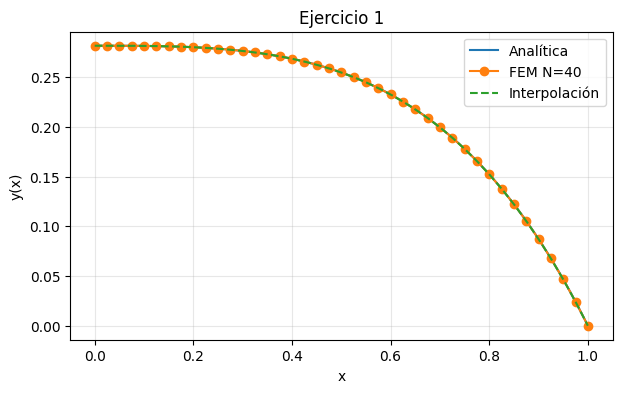


EJERCICIO 2
----------------------------------------
N =  10 | error_inf = 6.889815e-07 | error_rms = 4.645112e-07
N =  20 | error_inf = 4.289280e-08 | error_rms = 2.959884e-08 | orden ≈ 4.006
N =  40 | error_inf = 2.678176e-09 | error_rms = 1.870519e-09 | orden ≈ 4.001
N =  80 | error_inf = 1.673461e-10 | error_rms = 1.175988e-10 | orden ≈ 4.000


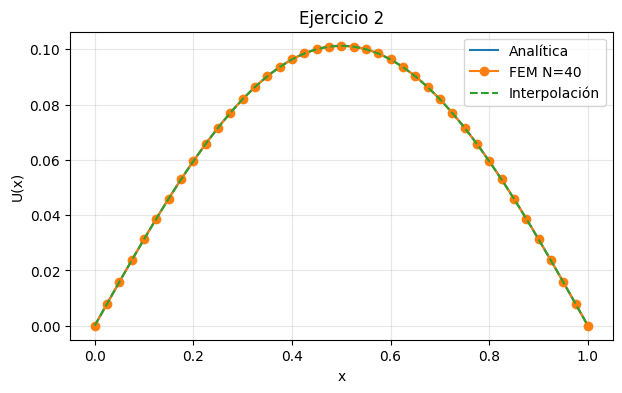

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

gp = 1.0 / np.sqrt(3.0)


# =========================
# Fuentes y soluciones exactas
# =========================

def f1(x):
    return x * np.exp(x)

def exact1(x):
    # Solución exacta que satisface y'' = -x e^x, y(0)=3-e, y(1)=0
    return 1.0 - np.e + np.exp(x) * (2.0 - x) - x

def f2(x):
    return np.sin(np.pi * x)

def exact2(x):
    return np.sin(np.pi * x) / (np.pi ** 2)


# =========================
# Núcleo FEM optimizado
# =========================

@njit(cache=True, fastmath=True)
def _source_term(x, problema):
    if problema == 1:
        return x * np.exp(x)
    else:
        return np.sin(np.pi * x)

@njit(cache=True, fastmath=True)
def _thomas(lower, diag, upper, rhs):
    n = diag.size
    c = upper.copy()
    d = rhs.copy()
    b = diag.copy()
    a = lower.copy()

    for i in range(1, n):
        m = a[i - 1] / b[i - 1]
        b[i] = b[i] - m * c[i - 1]
        d[i] = d[i] - m * d[i - 1]

    x = np.empty(n, dtype=np.float64)
    x[n - 1] = d[n - 1] / b[n - 1]
    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]
    return x

@njit(cache=True, fastmath=True)
def _fem_kernel(N, a, b, Ua, Ub, problema):
    nodes = np.linspace(a, b, N + 1)
    h = (b - a) / N
    nint = N - 1

    sol = np.empty(N + 1, dtype=np.float64)
    sol[0] = Ua
    sol[N] = Ub

    if nint <= 0:
        return nodes, sol

    lower = np.empty(nint - 1, dtype=np.float64) if nint > 1 else np.empty(0, dtype=np.float64)
    upper = np.empty(nint - 1, dtype=np.float64) if nint > 1 else np.empty(0, dtype=np.float64)
    diag = np.empty(nint, dtype=np.float64)
    rhs = np.zeros(nint, dtype=np.float64)

    for i in range(nint):
        diag[i] = 2.0 / h

    for i in range(nint - 1):
        lower[i] = -1.0 / h
        upper[i] = -1.0 / h

    for e in range(N):
        x1 = nodes[e]
        x2 = nodes[e + 1]
        he = x2 - x1

        fe0 = 0.0
        fe1 = 0.0

        for g in range(2):
            xi = -gp if g == 0 else gp
            N1 = 0.5 * (1.0 - xi)
            N2 = 0.5 * (1.0 + xi)
            x = 0.5 * (x1 + x2) + 0.5 * he * xi
            J = 0.5 * he
            s = _source_term(x, problema)
            fe0 += s * N1 * J
            fe1 += s * N2 * J

        if e > 0:
            rhs[e - 1] += fe0
        if e < N - 1:
            rhs[e] += fe1

    rhs[0] += Ua / h
    rhs[nint - 1] += Ub / h

    u_int = _thomas(lower, diag, upper, rhs)

    for i in range(1, N):
        sol[i] = u_int[i - 1]

    return nodes, sol


# =========================
# Versión general
# =========================

def FEM_general(N, f, xa, xb, Ua, Ub):
    nodes = np.linspace(xa, xb, N + 1)
    h = (xb - xa) / N
    nint = N - 1

    sol = np.empty(N + 1, dtype=float)
    sol[0] = Ua
    sol[N] = Ub

    if nint <= 0:
        return nodes, sol

    lower = np.full(nint - 1, -1.0 / h) if nint > 1 else np.empty(0, dtype=float)
    upper = np.full(nint - 1, -1.0 / h) if nint > 1 else np.empty(0, dtype=float)
    diag = np.full(nint, 2.0 / h, dtype=float)
    rhs = np.zeros(nint, dtype=float)

    for e in range(N):
        x1 = nodes[e]
        x2 = nodes[e + 1]
        he = x2 - x1

        fe0 = 0.0
        fe1 = 0.0

        for xi, w in ((-gp, 1.0), (gp, 1.0)):
            N1 = 0.5 * (1.0 - xi)
            N2 = 0.5 * (1.0 + xi)
            x = 0.5 * (x1 + x2) + 0.5 * he * xi
            J = 0.5 * he
            s = f(x)
            fe0 += s * N1 * w * J
            fe1 += s * N2 * w * J

        if e > 0:
            rhs[e - 1] += fe0
        if e < N - 1:
            rhs[e] += fe1

    rhs[0] += Ua / h
    rhs[nint - 1] += Ub / h

    u_int = _thomas(lower, diag, upper, rhs)

    for i in range(1, N):
        sol[i] = u_int[i - 1]

    return nodes, sol


def FEM(N, f, xa, xb, Ua, Ub):
    if f is f1:
        return _fem_kernel(N, xa, xb, Ua, Ub, 1)
    elif f is f2:
        return _fem_kernel(N, xa, xb, Ua, Ub, 2)
    else:
        return FEM_general(N, f, xa, xb, Ua, Ub)


# =========================
# Cálculo de errores
# =========================

def errores(x, u, exacta):
    ue = exacta(x)
    err_inf = np.max(np.abs(u - ue))
    err_rms = np.sqrt(np.mean((u - ue) ** 2))
    return err_inf, err_rms


# =========================
# Ejercicio 1
# =========================

xa, xb = 0.0, 1.0
Ua, Ub = 3.0 - np.e, 0.0
Ns = [10, 20, 40, 80]

print("EJERCICIO 1")
print("-" * 40)

prev = None
for N in Ns:
    xi, ui = FEM(N, f1, xa, xb, Ua, Ub)
    e_inf, e_rms = errores(xi, ui, exact1)
    if prev is None:
        print(f"N = {N:3d} | error_inf = {e_inf:.6e} | error_rms = {e_rms:.6e}")
    else:
        orden = np.log(prev / e_inf) / np.log(2.0)
        print(f"N = {N:3d} | error_inf = {e_inf:.6e} | error_rms = {e_rms:.6e} | orden ≈ {orden:.3f}")
    prev = e_inf

N_plot = 40
xi, ui = FEM(N_plot, f1, xa, xb, Ua, Ub)
x_new = np.linspace(xa, xb, 400)
y_new = np.interp(x_new, xi, ui)

plt.figure(figsize=(7, 4))
plt.plot(x_new, exact1(x_new), label="Analítica")
plt.plot(xi, ui, "o-", label=f"FEM N={N_plot}")
plt.plot(x_new, y_new, "--", label="Interpolación")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Ejercicio 1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# =========================
# Ejercicio 2
# =========================

xa, xb = 0.0, 1.0
Ua, Ub = 0.0, 0.0

print("\nEJERCICIO 2")
print("-" * 40)

prev = None
for N in Ns:
    xi, ui = FEM(N, f2, xa, xb, Ua, Ub)
    e_inf, e_rms = errores(xi, ui, exact2)
    if prev is None:
        print(f"N = {N:3d} | error_inf = {e_inf:.6e} | error_rms = {e_rms:.6e}")
    else:
        orden = np.log(prev / e_inf) / np.log(2.0)
        print(f"N = {N:3d} | error_inf = {e_inf:.6e} | error_rms = {e_rms:.6e} | orden ≈ {orden:.3f}")
    prev = e_inf

N_plot = 40
xi, ui = FEM(N_plot, f2, xa, xb, Ua, Ub)
x_new = np.linspace(xa, xb, 400)
y_new = np.interp(x_new, xi, ui)

plt.figure(figsize=(7, 4))
plt.plot(x_new, exact2(x_new), label="Analítica")
plt.plot(xi, ui, "o-", label=f"FEM N={N_plot}")
plt.plot(x_new, y_new, "--", label="Interpolación")
plt.xlabel("x")
plt.ylabel("U(x)")
plt.title("Ejercicio 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()